# Módulo 7 · Clase 4 — Las máquinas que ven

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### La última clase, en siete partes

1. **La solución del reto** — Fashion-MNIST, resuelto como se corrige un
   examen.
2. **La GPU** — por qué existe, la historia de NVIDIA, y el botón de Colab.
3. **El mapa de la visión por computadora** — las tareas, y en qué se
   diferencian.
4. **Cada tarea, con código** — cuatro modelos, la misma línea, y la perilla
   del umbral.
5. **El ojo por código** — Gemini multimodal llamado desde una celda, con la
   llave de la clase.
6. **El oído por código** — Whisper: dictan al micrófono, el modelo
   transcribe *en su Colab*.
7. **Los peligros, con nombre** — la promesa pendiente, pagada.

> **La llave de la clase** llega por el chat del curso. Va directo a los
> **Secrets de Colab** (el candadito 🔑 del panel izquierdo), con el nombre
> `LLAVE_CLASE`. Nunca pegada en una celda — y al final de la clase la
> **revocamos en vivo**: eso también es parte de la lección.

**Su entrega es el jueves.** Todo lo de hoy suma piezas para ella.

## 0 · Preparación

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import google.colab              # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

print("listo. ¿en Colab?", EN_COLAB)

listo. ¿en Colab? False


---

# 1 · La solución del reto: Fashion-MNIST

El reto venció, así que aquí está — como se entrega un examen corregido. Es
**exactamente la misma red** que leyó dígitos, con el dato cambiado:

In [2]:
# la carga -- identica a la del reto
PRENDAS = ["camiseta/top", "pantalón", "suéter", "vestido", "abrigo",
           "sandalia", "camisa", "zapatilla", "bolso", "botín"]

try:
    from tensorflow import keras
    TF = True
    (x_ent, y_ent), (x_exa, y_exa) = keras.datasets.fashion_mnist.load_data()
    print(f"entrenamiento: {x_ent.shape} | examen: {x_exa.shape}")
except ImportError:
    TF = False
    print("TensorFlow no está en este entorno; en Colab ya viene instalado.")

/private/tmp/claude-501/-Users-cmosquerat-Documents-GitHub-slb-diplomado/17ff0dd6-d936-43c0-bd10-f0fc4e571d53/scratchpad/v7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


entrenamiento: (60000, 28, 28) | examen: (10000, 28, 28)


In [3]:
# la misma receta de los digitos: normalizar, aplanar, Dense(128)->Dense(10)
if TF:
    import tensorflow as tf
    tf.random.set_seed(0)

    Xe = (x_ent / 255.0).reshape(len(x_ent), -1)
    Xx = (x_exa / 255.0).reshape(len(x_exa), -1)

    red = keras.Sequential([
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    red.compile(optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])
    historia = red.fit(Xe, y_ent, epochs=8, validation_split=0.1, verbose=2)

Epoch 1/8


1688/1688 - 1s - 659us/step - accuracy: 0.8224 - loss: 0.5094 - val_accuracy: 0.8378 - val_loss: 0.4490


Epoch 2/8


1688/1688 - 1s - 503us/step - accuracy: 0.8627 - loss: 0.3830 - val_accuracy: 0.8598 - val_loss: 0.4026


Epoch 3/8


...

1688/1688 - 1s - 504us/step - accuracy: 0.8975 - loss: 0.2796 - val_accuracy: 0.8812 - val_loss: 0.3396


Epoch 7/8


1688/1688 - 1s - 503us/step - accuracy: 0.9033 - loss: 0.2659 - val_accuracy: 0.8833 - val_loss: 0.3367


Epoch 8/8


1688/1688 - 1s - 504us/step - accuracy: 0.9075 - loss: 0.2534 - val_accuracy: 0.8822 - val_loss: 0.3379


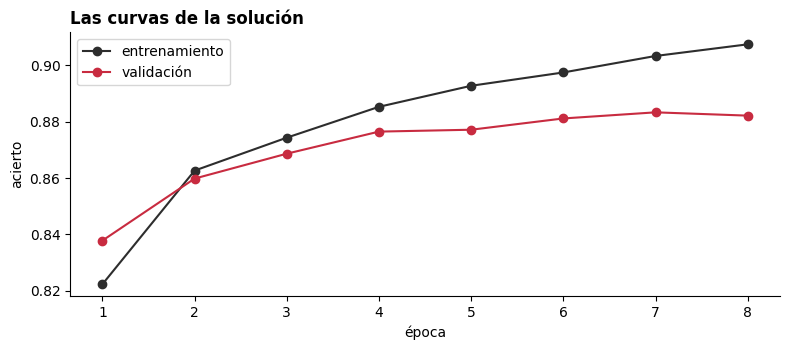

In [4]:
# las curvas: el overfitting, visto
if TF:
    h = historia.history
    ep = range(1, len(h["accuracy"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(ep, h["accuracy"], "o-", label="entrenamiento", color="#2D2D2D")
    ax.plot(ep, h["val_accuracy"], "o-", label="validación", color="#C82B40")
    ax.set_xlabel("época"); ax.set_ylabel("acierto")
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)
    ax.set_title("Las curvas de la solución", loc="left", fontweight="bold")
    plt.tight_layout(); plt.show()

examen: 0.873   (los dígitos daban ~0.98)


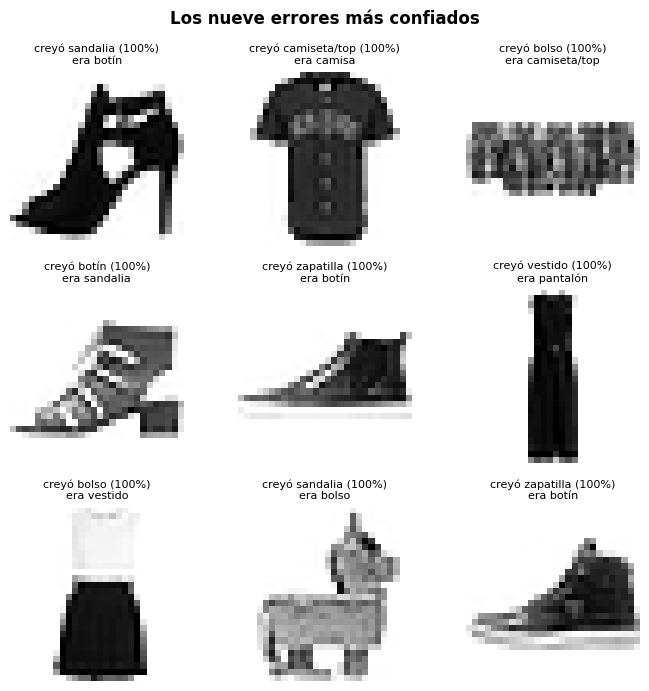

In [5]:
# el examen, UNA vez -- y los errores mirados a la cara
if TF:
    _, acc = red.evaluate(Xx, y_exa, verbose=0)
    print(f"examen: {acc:.3f}   (los dígitos daban ~0.98)")

    proba = red.predict(Xx, verbose=0)
    pred = proba.argmax(axis=1)

    mal = np.where(pred != y_exa)[0]
    conf = proba[mal, pred[mal]]
    peores = mal[np.argsort(conf)[::-1][:9]]

    fig, axes = plt.subplots(3, 3, figsize=(7, 7))
    for ax, i in zip(axes.ravel(), peores):
        ax.imshow(x_exa[i], cmap="gray_r")
        ax.set_title(f"creyó {PRENDAS[pred[i]]} ({100*proba[i, pred[i]]:.0f}%)\n"
                     f"era {PRENDAS[y_exa[i]]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Los nueve errores más confiados", fontweight="bold")
    plt.tight_layout(); plt.show()

### Las tres lecciones de la solución

1. **La dificultad vive en el dato, no en la arquitectura.** La misma red:
   ~98 % en dígitos, ~87–88 % en ropa.
2. **Las confusiones son las humanas**: camiseta↔camisa, abrigo↔suéter. En
   28×28 píxeles, ustedes también dudarían — miren los errores de arriba.
3. **El techo no se sube con más épocas** (eso solo memoriza — lo dicen sus
   curvas). Se sube cambiando de arquitectura: una que entienda que un
   píxel y sus vecinos forman *texturas y bordes*. Esa idea se llama
   **convolución** — y es la puerta de todo lo que sigue hoy.

---

# 2 · Un paréntesis que vale billones: la GPU

¿Notaron que entrenar la red de arriba **tardó**? Corrió en la **CPU** — y
antes de pasar a los modelos que ven, conviene entender por qué eso importa.

### CPU y GPU, desde cero

- La **CPU** tiene unos pocos núcleos, rapidísimos y versátiles: hacen
  *cualquier* cosa, una tras otra. Es un cirujano.
- La **GPU** tiene **miles** de núcleos pequeños que hacen *la misma
  operación sobre muchos datos a la vez*. Es una cuadrilla de mil obreros
  haciendo el mismo movimiento.

Una red neuronal es, por dentro, casi pura **multiplicación de matrices** —
millones de multiplicaciones idénticas e independientes. Exactamente el
trabajo de la cuadrilla.

### La historia, en cuatro fechas

- **1993** — nace NVIDIA para una sola cosa: dibujar videojuegos (millones
  de píxeles en paralelo — la misma matemática, sin que nadie lo supiera
  aún).
- **2007** — CUDA: NVIDIA abre sus tarjetas al cómputo general. Los
  científicos empiezan a usarlas para todo lo que sea paralelo.
- **2012** — el momento bisagra: **AlexNet**, una red entrenada en **dos
  GPUs de videojuegos**, arrasa la competencia de reconocimiento de
  imágenes ImageNet. Arranca la era del deep learning.
- **2026** — NVIDIA es una de las empresas más valiosas del mundo (del
  orden de los **4 billones de dólares** — billones *en español*: millones
  de millones, lo que la prensa en inglés llama *trillions*), y las GPUs
  son el recurso
  estratégico de la IA: se compran por decenas de miles, con listas de
  espera y geopolítica de por medio.

### Y el botón que a ustedes les toca

En Colab: **Entorno de ejecución → Cambiar tipo de entorno → GPU (T4)** —
gratis. Con eso, la red de arriba entrena en segundos en vez de minutos, y
los modelos de visión vuelan.

> ⚠️ Al cambiar el tipo de entorno, **la sesión se reinicia**: hay que
> volver a correr las celdas desde el principio. Háganlo ahora, antes de
> la parte de visión.

In [6]:
# ¿que acelerador tenemos? (si dice "no encontrado", aun estan en CPU)
if EN_COLAB:
    !nvidia-smi -L
else:
    print("fuera de Colab: sin GPU que revisar")

fuera de Colab: sin GPU que revisar


---

# 3 · El mapa: las tareas de la visión por computadora

Un dato para calibrar lo que están a punto de correr: en **1966**, el MIT
asignó «resolver la visión por computadora» como **proyecto de verano** para
estudiantes. Tomó **46 años** — décadas de reglas escritas a mano que nunca
alcanzaron, hasta que en 2012 AlexNet (la misma historia de la GPU) demostró
que la salida era *aprender* de ejemplos, no programar reglas. Todo lo de
hoy existe porque esa apuesta ganó.

Cada tarea es una **pregunta distinta** sobre la misma imagen — y saber cuál
pedir es el 80 % del trabajo:

| Tarea | La pregunta | Ejemplo en su mundo |
|---|---|---|
| **Clasificación** | ¿*qué* es esta imagen? | ¿esta junta está corroída o sana? |
| **Detección** | ¿*qué* hay, y *dónde*? | cascos y chalecos en la cámara de planta |
| **Segmentación** | ¿*qué píxeles* exactamente? | el área exacta de la mancha o el derrame |
| **Pose** | ¿en qué *posición* está el cuerpo? | ergonomía; persona caída |
| **OCR / lectura** | ¿qué *dice*? | medidores análogos, placas, documentos |
| **Multimodal** | *cualquier* pregunta en lenguaje natural | «describe esta foto de inspección» |

Las cuatro primeras las vamos a correr **con código, una por una**. Las dos
últimas, con el ojo por código de la parte 5.

---

# 4 · Cada tarea, con código

**Ultralytics** publica los cuatro modelos preentrenados, y los cuatro se
usan con **la misma línea**. La instalación tarda ~1 minuto:

In [7]:
if EN_COLAB:
    %pip install -q ultralytics

try:
    from ultralytics import YOLO
    ULTRA = True
except ImportError:
    ULTRA = False
    print("ultralytics no está en este entorno; en Colab: la celda de arriba")

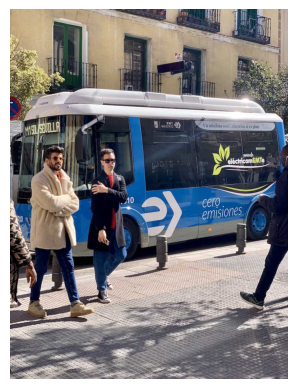

In [8]:
# la foto de prueba de la clase (despues: las suyas)
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ultralytics/ultralytics/"
    "main/ultralytics/assets/bus.jpg", "foto.jpg")
plt.imshow(plt.imread("foto.jpg")); plt.axis("off"); plt.show()

### 4.1 · Clasificación — ¿qué es?

Un modelo, una línea, y el resultado se **lee**, no solo se mira:

In [9]:
if ULTRA:
    r = YOLO("yolo11n-cls.pt")("foto.jpg", verbose=False)[0]

    # el objeto de resultados: r.probs trae las probabilidades por clase
    print("las 3 mejores apuestas del modelo:")
    for i in r.probs.top5[:3]:
        print(f"  {r.names[i]:20s} {float(r.probs.data[i]):.2f}")

las 3 mejores apuestas del modelo:
  minibus              0.57
  police_van           0.34
  trolleybus           0.04


**Fíjense: el modelo DUDA** — minibus 0.57, police_van 0.34. Una sola
etiqueta para toda la imagen es poco cuando la imagen tiene muchas cosas.
Por eso existe la siguiente tarea.

### 4.2 · Detección — ¿qué y dónde?

conteo por tipo: {'bus': 1, 'person': 4}
confianzas: [0.94, 0.89, 0.88, 0.86, 0.62]


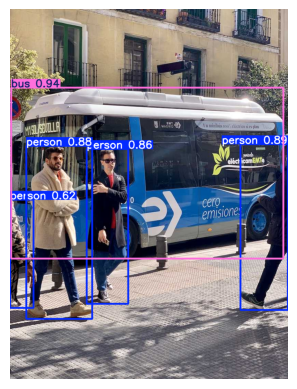

In [10]:
if ULTRA:
    r = YOLO("yolo11n.pt")("foto.jpg", verbose=False)[0]

    # r.boxes: una caja por objeto -- clase, confianza y coordenadas
    import collections
    conteo = collections.Counter(r.names[int(c)] for c in r.boxes.cls)
    print("conteo por tipo:", dict(conteo))
    print("confianzas:", [round(float(c), 2) for c in r.boxes.conf])

    plt.imshow(r.plot()[:, :, ::-1]); plt.axis("off"); plt.show()

Esto ya es una herramienta: **el conteo sale de `r.boxes`, no del dibujo**.
Una app de EPP filtra esas cajas («persona sin casco») — no mira la imagen
bonita.

### 4.3 · Segmentación — ¿qué píxeles?

máscaras: (6, 640, 480) (objetos, alto, ancho)
el primer objeto ocupa 92.230 píxeles


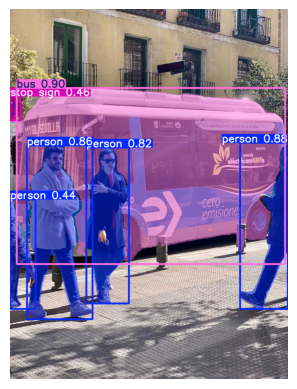

In [11]:
if ULTRA:
    r = YOLO("yolo11n-seg.pt")("foto.jpg", verbose=False)[0]

    # r.masks: una mascara por objeto -- los pixeles exactos
    print("máscaras:", tuple(r.masks.data.shape), "(objetos, alto, ancho)")
    px_bus = int(r.masks.data[0].sum())
    print(f"el primer objeto ocupa {px_bus:,} píxeles".replace(",", "."))

    plt.imshow(r.plot()[:, :, ::-1]); plt.axis("off"); plt.show()

La máscara permite **medir**: área de la mancha, fracción de la imagen,
crecimiento entre dos fotos. La caja dice *dónde*; la máscara dice *cuánto*.

### 4.4 · Pose — ¿en qué posición?

personas: 4
puntos por persona: (17, 3) (17 articulaciones × x, y, confianza)


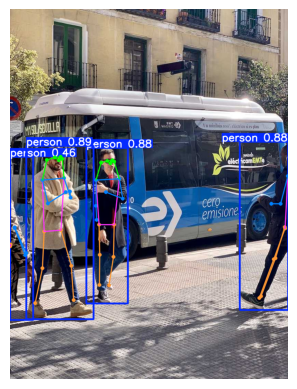

In [12]:
if ULTRA:
    r = YOLO("yolo11n-pose.pt")("foto.jpg", verbose=False)[0]

    # r.keypoints: 17 puntos del cuerpo por persona (x, y, confianza)
    print(f"personas: {len(r.keypoints)}")
    print("puntos por persona:", tuple(r.keypoints.data.shape[1:]),
          "(17 articulaciones × x, y, confianza)")

    plt.imshow(r.plot()[:, :, ::-1]); plt.axis("off"); plt.show()

Con 17 puntos por persona se responde «¿está agachado?», «¿levantó los
brazos?», «¿hay alguien en el suelo?» — reglas de seguridad escritas sobre
geometría.

### 4.5 · La perilla que hay que conocer: el umbral de confianza

El detector no dice «hay un bus»: dice «bus, con confianza 0.94». El
parámetro `conf` decide desde qué confianza se **reporta** — y moverlo
cambia el resultado:

In [13]:
if ULTRA:
    import collections
    modelo = YOLO("yolo11n.pt")
    for umbral in [0.6, 0.25, 0.1]:
        r = modelo("foto.jpg", conf=umbral, verbose=False)[0]
        conteo = collections.Counter(r.names[int(c)] for c in r.boxes.cls)
        print(f"umbral {umbral}: {dict(conteo)}")

umbral 0.6: {'bus': 1, 'person': 4}
umbral 0.25: {'bus': 1, 'person': 4}
umbral 0.1: {'bus': 1, 'person': 4, 'skateboard': 1}


Lean el experimento: con umbral 0.6 y 0.25 el resultado es **idéntico** (la
detección más tímida es una persona al 62 %). Pero al bajarlo a 0.1 aparece
un **monopatín al 12 % que no existe en la foto**. Umbral alto = se pierden
objetos reales; umbral bajo = entran fantasmas. En una app de seguridad esa
perilla es una decisión de negocio: ¿qué cuesta más — una alarma falsa o un
casco sin detectar?

### 4.6 · ¿De dónde salen las 80 clases? (y qué pasa con las SUYAS)

El detector conoce 80 objetos porque se entrenó con **COCO**, un dataset de
330.000 fotos cotidianas etiquetadas a mano. Por eso sabe qué es un frisbee
y **no sabe qué es una válvula**: el modelo solo conoce lo que su dataset le
enseñó — el sesgo de catálogo.

¿Y si su problema necesita «casco de la empresa» o «brida corroída»? Se hace
**ajuste fino** (*fine-tuning*): se toman 50–200 fotos propias, se etiquetan
(hay herramientas gratuitas para eso), y se re-entrena el modelo
preentrenado con `modelo.train(data="mis_fotos.yaml", epochs=50)`. No lo
corremos hoy — pero sepan que existe, que es *una línea*, y que es lo
primero que van a necesitar cuando esto toque su trabajo real.

### 4.7 · Ahora con SUS fotos

Suban una foto (panel 📁 de Colab), cambien `"foto.jpg"` por el nombre de la
suya en cualquiera de las celdas de arriba, y vuelvan a correr.

> ⚠️ La regla de siempre: nada de instalaciones de la empresa, documentos,
> ni personas sin permiso.

**Anoten un acierto y un fallo.** El detector más usado del mundo también se
equivoca, y saberlo es parte de usarlo.

---

# 5 · El ojo por código: Gemini multimodal desde la celda

Las tareas de arriba tienen **catálogos fijos** (80 clases, 17 puntos). Para
la pregunta libre — «¿cuántas personas llevan casco?», «¿qué marca este
medidor?» — se llama a un modelo multimodal **por código**.

### La llave de la clase

1. Copien la llave del **chat del curso**.
2. Panel izquierdo de Colab → 🔑 **Secrets** → `+ Agregar` → nombre
   `LLAVE_CLASE`, valor: la llave. Activen «acceso del cuaderno».
3. **Nunca** la peguen en una celda — la celda se comparte; el secret no.

> Al final de la clase la **revocamos en vivo**. Una llave compartida es una
> llave quemada: por eso se rota. Eso es gestión de secretos, y lo acaban de
> practicar.

In [14]:
# conectar con la llave (solo funciona en Colab con el secret creado)
try:
    from google.colab import userdata
    from google import genai        # si faltara: %pip install -q google-genai
    llave = userdata.get("LLAVE_CLASE")
    cliente = genai.Client(api_key=llave)
    GEMINI = True
    print("conectado")
except Exception as e:              # noqa: BLE001
    GEMINI = False
    print("sin conexión a Gemini en este entorno:", type(e).__name__)

sin conexión a Gemini en este entorno: ModuleNotFoundError


In [15]:
# tres preguntas sobre la MISMA foto -- describir, contar, leer
if GEMINI:
    from PIL import Image
    foto = Image.open("foto.jpg")

    for pregunta in [
        "Describe esta foto en dos frases, en español.",
        "¿Cuántas personas se ven? Responde solo el número.",
        "¿Qué texto se alcanza a leer en la imagen? Lístalo.",
    ]:
        r = cliente.models.generate_content(
            model="gemini-2.5-flash", contents=[foto, pregunta])
        print(f"» {pregunta}\n{r.text.strip()}\n")

**Prueben con las suyas:** la foto de un medidor y *«¿qué valor marca?»*; la
de un tablero y *«transcribe lo que dice»*; la de un estante y *«cuenta las
cajas»*. OCR y pregunta libre, en tres líneas de código.

**Plan B** (si la llave no funciona en su cuenta): el panel de Gemini de
Colab acepta imágenes — misma pregunta, sin código. Pero la versión por
código es la que se integra a una app.

**Y la advertencia que ya conocen elevada al cubo:** cada foto que mandan
por esta vía **sale de su computador hacia un tercero**. Con la foto de
prueba, ningún problema. Con una foto de la planta — eso es exactamente el
tema de la parte 7.

---

# 6 · El oído por código: Whisper

La visión no es el único sentido que ya viene preentrenado. **Whisper** es
el modelo de reconocimiento de voz que OpenAI liberó como **código abierto**
en 2022: entrenado con 680.000 horas de audio, transcribe español (y 98
idiomas más) con un `pip install`.

Y trae una diferencia **importante** frente a Gemini: Whisper corre
**dentro de su Colab**. El audio no viaja a ningún tercero — el modelo se
descarga una vez y trabaja local. La misma tarea, dos arquitecturas de
privacidad opuestas. Elegir entre ellas también es una decisión de
ingeniería.

**El plan:** dictan un reporte de campo al micrófono → Whisper lo vuelve
texto (local) → Gemini vuelve ese texto un **acta estructurada**. Voz →
texto → estructura: el flujo completo, en tres celdas.

In [16]:
if EN_COLAB:
    %pip install -q openai-whisper

try:
    import whisper
    WHISPER = True
except ImportError:
    WHISPER = False
    print("whisper no está en este entorno; en Colab: la celda de arriba")

In [17]:
# grabar desde el microfono del navegador (pide permiso la primera vez)
if EN_COLAB:
    from IPython.display import Javascript, display
    from google.colab import output
    from base64 import b64decode

    JS_GRABAR = '''
    const b2texto = blob => new Promise(listo => {
      const lector = new FileReader()
      lector.onloadend = e => listo(e.srcElement.result)
      lector.readAsDataURL(blob)
    })
    var grabar = ms => new Promise(async listo => {
      const stream = await navigator.mediaDevices.getUserMedia({audio: true})
      const grabadora = new MediaRecorder(stream)
      const trozos = []
      grabadora.ondataavailable = e => trozos.push(e.data)
      grabadora.onstop = async () => listo(await b2texto(new Blob(trozos)))
      grabadora.start()
      await new Promise(r => setTimeout(r, ms))
      grabadora.stop()
    })
    '''

    def grabar(segundos=15, archivo="reporte.webm"):
        display(Javascript(JS_GRABAR))
        print(f"🎙️ grabando {segundos} segundos... hable ya")
        datos = output.eval_js(f"grabar({segundos * 1000})")
        with open(archivo, "wb") as f:
            f.write(b64decode(datos.split(",")[1]))
        print("listo:", archivo)
        return archivo

    # dicten un reporte como si llamaran desde campo, por ejemplo:
    #   "Inspección del tanque tres. Se observa corrosión en la brida norte.
    #    Presión registrada: mil doscientos cincuenta psi. Se recomienda
    #    cambio de empaque antes del viernes."
    AUDIO = grabar(15)
else:
    AUDIO = None
    print("el micrófono del navegador solo está disponible en Colab")

el micrófono del navegador solo está disponible en Colab


In [18]:
# transcribir -- local, dentro de SU sesion
if WHISPER and AUDIO:
    modelo_voz = whisper.load_model("base")     # 74 MB, se descarga una vez
    resultado = modelo_voz.transcribe(AUDIO, language="es")
    TEXTO = resultado["text"].strip()
    print(TEXTO)

In [19]:
# el paso final: de la transcripcion al acta -- ahora si, con Gemini
if GEMINI and WHISPER and AUDIO:
    r = cliente.models.generate_content(
        model="gemini-2.5-flash",
        contents=f'''Este es un reporte de campo dictado por voz:

"{TEXTO}"

Conviértelo en un acta breve con este formato:
- RESUMEN: (una frase)
- DATOS: (lista de equipos, valores y unidades mencionados)
- ACCIONES: (lista de lo que se pide hacer, con plazo si lo hay)''')
    print(r.text.strip())

Léanlo dos veces: dictaron **quince segundos** y tienen un acta con los
datos y las acciones separados — lista para pegarse en un correo o en un
sistema. Eso, hace tres años, era un producto que se compraba. Hoy son tres
celdas.

**Ojo a la frontera de privacidad que acaban de cruzar dos veces:** el
*audio* nunca salió de su Colab (Whisper es local); el *texto* sí viajó a
Gemini. Si el reporte tuviera datos confidenciales, este diseño les permite
decidir **qué cruza y qué no** — de eso, la parte que sigue.

---

# 7 · Los peligros, con nombre

La promesa pendiente desde la Clase 1. Cuatro peligros, sus caras, y su
defensa — que ya practicaron sin saberlo.

### 7.1 · Lo que se pega en un chat de IA, sale de la empresa

Los proveedores de estos servicios pueden **retener** lo que se les envía —
prompts, datos, fotos — por meses, y **personas** pueden revisarlo (está en
la letra chica de casi todos, incluido el Gemini de Colab: retención de
hasta 18 meses, revisores humanos).

**La regla operativa:**
- El dato confidencial **no se pega**: producción real, presiones,
  coordenadas, nombres de pozos o clientes, fotos de instalaciones.
- El **esquema sí**: nombres de columnas y tipos, sin valores. Con eso el
  agente escribe el código, y el código corre localmente sobre el dato real.
- En la duda: **pregunten a seguridad de la información antes, no después**.

### 7.2 · Las llaves son contraseñas

Lo acaban de vivir: la llave fue al **Secret**, no a la celda. Un cuaderno
se comparte, se sube a un repositorio, se proyecta en una reunión — y una
llave pegada en una celda queda expuesta en todos esos lugares. Las llaves
se guardan en secrets, **se rotan**, y se revocan cuando se comparten de
más. La nuestra muere hoy — mírenlo pasar.

### 7.3 · Las librerías alucinadas

Un agente puede recomendar con total confianza una librería **que no
existe** — o peor: que existe porque alguien la registró con el nombre que
los agentes suelen inventar, cargada de código malicioso (*typosquatting*).

**La defensa:** antes de `pip install` de algo que no conocen, 30 segundos:
¿existe en PyPI? ¿cuántas descargas? ¿desde cuándo? Si el agente insiste en
una librería exótica para algo que pandas ya hace — desconfíen.

### 7.4 · El peor de todos: código que corre y está mal

No lanza error. Produce un número. El número es basura. Ya lo vieron tres
veces en este módulo: las propinas en efectivo, la columna `alive`, el
tasador de la piedra de 0 mm.

**La defensa es la de la Clase 1**, y no caduca:
1. ¿Cuántas filas entraron y cuántas salieron?
2. ¿Hay ceros, vacíos o números perfectos sospechosos?
3. ¿El resultado tiene sentido físico o de negocio?
4. ¿Qué decisión se toma con esto, y qué pasa si está mal?

---

# 8 · Cierre del módulo — y su entrega

## La entrega del jueves

Equipos de hasta 3. El cuaderno del Titanic es la plantilla. Se entrega:

- [ ] El **cuaderno** con el flujo completo: EDA → limpieza con decisiones
  escritas → comparación de modelos → examen reservado → explicabilidad
- [ ] La **app** con su link funcionando
- [ ] Los **prompts** que usaron
- [ ] **Un error del agente que ustedes cazaron**, y cómo lo detectaron
- [ ] Qué **decisión** habilita la herramienta, y para quién

## El arco del módulo, en cuatro clases

| Clase | Lo que quedó |
|---|---|
| 1 | Dirigir un agente: los cuatro fundamentos, y verificar siempre |
| 2 | Un modelo servido: certificar, entrenar, examinar, blindar |
| 3 | El flujo profesional (GridSearch, SHAP) — y su primera red |
| 4 | Las máquinas que ven — y oyen: visión, voz, y los peligros con nombre |

## La puesta en común

Antes de cerrar, tres preguntas para la sala — una respuesta por equipo:

1. ¿Qué proceso de su trabajo **automatizarían el lunes** con lo visto en el
   módulo?
2. ¿Cuál fue el **error del agente** que cazaron esta semana, y cómo lo
   detectaron?
3. ¿Qué decisión **no le delegarían jamás** a un modelo, por buena que sea
   su métrica?

## Si se llevan una sola cosa del módulo

> **El agente escribe. Ustedes responden.** Escribir se volvió barato; el
> criterio para especificar bien, verificar siempre y desconfiar de lo
> perfecto — eso es lo que ustedes ponen, y vale más ahora que hace tres
> años.

Gracias por estas cuatro clases. Nos vemos el jueves con sus entregas.

---

*Machine Learning for Petroleum Engineers Using Python* · SLB Ecuador / UDLA
· 2026